In [1]:
!pip install -q -U "transformers>=4.52.0"
!pip install "accelerate>=0.31.0" bitsandbytes datasets evaluate scikit-learn pandas numpy matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 103.5 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompati

In [2]:
import os, re, gc, json, time, random, warnings
from pathlib import Path
from typing import Any, Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    classification_report,
    confusion_matrix,
)

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [3]:
from datasets import load_dataset

# Load CLARITY
DATASET_NAME = "ailsntua/QEvasion"

dataset = load_dataset(DATASET_NAME)

print(dataset)

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas() if "test" in dataset else None

print("Original train shape:", train_df.shape)
if test_df is not None:
    print("Original test shape:", test_df.shape)


# -------------------------------------------------------------------
# column rename (για να τα βρισκει ο agent)
# -------------------------------------------------------------------

COLUMN_RENAME = {
    "question": "question",
    "interview_answer": "answer",
    "clarity_label": "label",
    "index": "id",
}

train_df = train_df.rename(columns=COLUMN_RENAME)

if test_df is not None:
    test_df = test_df.rename(columns=COLUMN_RENAME)



print("\nAfter renaming:")
print("train columns:", train_df.columns.tolist())
if test_df is not None:
    print("test columns:", test_df.columns.tolist())

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 3448
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label'],
        num_rows: 308
    })
})
Original train shape: (3448, 20)
Original test shape: (308, 20)

After renaming:
train columns: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'q

Επιλέγουμε τώρα να εφαρμόσουμε έναν ελάχιστο και μη παρεμβατικό καθαρισμό, ο οποίος περιορίζεται στην αφαίρεση περιττών κενών διαστημάτων και στη διαχείριση τυχόν ελλιπών τιμών, παράλληλα με την ομαλοποίηση των ετικετών (labels). Αποφύγαμε εσκεμμένα τεχνικές όπως η αφαίρεση stop-words, το stemming ή η καθολική μετατροπή σε πεζά γράμματα, αφού, καθώς η αρχιτεκτονική μας βασίζεται σε ένα instruction-tuned μεγάλο γλωσσικό μοντέλο (Qwen3.5-0.8B) και σε ένα Multi-Agent σύστημα, η διατήρηση της φυσικής δομής της γλώσσας είναι κρίσιμη. Το μοντέλο χρειάζεται ανέπαφη τη συντακτική δομή, τα σημεία στίξης, τα κεφαλαία γράμματα και το πλήρες περιβάλλον (context) του κειμένου προκειμένου να αξιολογήσει με ακρίβεια λεπτές γλωσσικές αποχρώσεις, όπως η πολιτική υπεκφυγή, η ειρωνεία ή η ασάφεια. Οποιαδήποτε επιπλέον αλλοίωση του κειμένου θα στερούσε από τους πράκτορες (agents) πολύτιμη πληροφορία, μειώνοντας την ικανότητα συλλογισμού τους.

In [4]:
LABELS = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]

NUMERIC_LABEL_MAP = {
    0: "Clear Reply", #integer
    1: "Ambivalent",
    2: "Clear Non-Reply",
    "0": "Clear Reply", #string
    "1": "Ambivalent",
    "2": "Clear Non-Reply",
}

LABEL_ALIASES = {
    "clear reply": "Clear Reply",
    "clear_reply": "Clear Reply",
    "reply": "Clear Reply",
    "clear": "Clear Reply",
    "clear reply.": "Clear Reply", 
    "yes": "Clear Reply", #δλδ απαντάει "ναι", εννοώντας ότι απάντησε ο πολιτικός όντως

    "ambivalent": "Ambivalent",
    "ambiguous": "Ambivalent",
    "partial": "Ambivalent",
    "partially clear": "Ambivalent",
    "ambivalent.": "Ambivalent",   # Αν βάλει τελεία
    "unclear": "Ambivalent",       
    "neutral": "Ambivalent",

    "clear non-reply": "Clear Non-Reply",
    "clear non reply": "Clear Non-Reply",
    "clear_non_reply": "Clear Non-Reply",
    "non-reply": "Clear Non-Reply",
    "non reply": "Clear Non-Reply",
    "nonreply": "Clear Non-Reply",
    "clear non-reply.": "Clear Non-Reply", # Αν βάλει τελεία
    "evasion": "Clear Non-Reply",          # Λόγω ονόματος dataset 
    "no": "Clear Non-Reply",
}

QUESTION_CANDIDATES = ["question", "Question", "q", "prompt", "query"]
ANSWER_CANDIDATES = [
    "answer",
    "Answer",
    "interview_answer",
    "response",
    "Response",
    "reply",
    "Reply"
]
LABEL_CANDIDATES = [
    "label",
    "Label",
    "clarity_label",
    "target",
    "Target",
    "class",
    "Class",
    "clarity",
    "Clarity"
]
ID_CANDIDATES = ["id", "ID", "Id", "index", "Index"]


def find_column(df, candidates, required=True):
    lower_to_original = {c.lower(): c for c in df.columns}

    for cand in candidates:
        if cand in df.columns:
            return cand

        if cand.lower() in lower_to_original:
            return lower_to_original[cand.lower()]

    if required:
        raise ValueError(
            f"Could not find any of {candidates}. "
            f"Existing columns: {list(df.columns)}"
        )

    return None

question_col = find_column(train_df, QUESTION_CANDIDATES)
answer_col = find_column(train_df, ANSWER_CANDIDATES)
label_col = find_column(train_df, LABEL_CANDIDATES)
id_col = find_column(train_df, ID_CANDIDATES, required=False)

print("question_col:", question_col)
print("answer_col:", answer_col)
print("label_col:", label_col)
print("id_col:", id_col)


train_df[question_col] = train_df[question_col].fillna("").str.strip()
train_df[answer_col] = train_df[answer_col].fillna("").str.strip()

if test_df is not None:
    test_question_col = find_column(test_df, QUESTION_CANDIDATES)
    test_answer_col = find_column(test_df, ANSWER_CANDIDATES)
    
    if test_question_col != question_col:
        test_df[question_col] = test_df[test_question_col]
    if test_answer_col != answer_col:
        test_df[answer_col] = test_df[test_answer_col]

    test_df[question_col] = test_df[question_col].fillna("").str.strip()
    test_df[answer_col] = test_df[answer_col].fillna("").str.strip()


def normalize_label(x):
    if pd.isna(x):
        return None

    if x in NUMERIC_LABEL_MAP:
        return NUMERIC_LABEL_MAP[x]

    s = str(x).strip()

    if s in NUMERIC_LABEL_MAP:
        return NUMERIC_LABEL_MAP[s]

    if s in LABELS:
        return s

    key = re.sub(r"\s+", " ", s.lower().replace("_", " ")).strip()

    if key in LABEL_ALIASES:
        return LABEL_ALIASES[key]

    if "non" in key and "reply" in key:
        return "Clear Non-Reply"

    if "ambiv" in key or "ambig" in key or "partial" in key:
        return "Ambivalent"

    if "clear" in key or "reply" in key:
        return "Clear Reply"

    return None



train_df = train_df.copy()
train_df["label_norm"] = train_df[label_col].apply(normalize_label)

print("\nLabel distribution:")
print(train_df["label_norm"].value_counts(dropna=False))

if train_df["label_norm"].isna().any():
    bad_labels = train_df.loc[train_df["label_norm"].isna(), label_col].unique()
    raise ValueError(f"Some labels could not be normalized: {bad_labels}")

display(train_df[[question_col, answer_col, label_col, "label_norm"]].head())

question_col: question
answer_col: answer
label_col: label
id_col: id

Label distribution:
label_norm
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64


,question,answer,label,label_norm
0,How would you respond to the accusation that t...,"Well, look, first of all, theI am sincere abou...",Clear Reply,Clear Reply
1,Do you think President Xi is being sincere abo...,"Well, look, first of all, theI am sincere abou...",Ambivalent,Ambivalent
2,Do you believe the country's slowdown and grow...,"Look, I think China has a difficult economic p...",Ambivalent,Ambivalent
3,Are you worried about the meeting between Pres...,"Look, I think China has a difficult economic p...",Ambivalent,Ambivalent
4,Is the President's engagement with Asian count...,"Well, I hope I get to see Mr. Xi sooner than l...",Clear Reply,Clear Reply


Σε συστήματα που βασίζονται σε prompting και agents, ο διαχωρισμός των δεδομένων είναι απαραίτητος για την αποφυγή του **Prompt Overfitting**. 

Όταν τροποποιούμε διαρκώς τις οδηγίες των 4 πρακτόρων για να διορθώσουμε συγκεκριμένα λάθη, υπάρχει κίνδυνος να τις υπερ-βελτιστοποιήσουμε μόνο για αυτά τα παραδείγματα, χάνοντας την ικανότητα γενίκευσης.

### Διαχωρισμός στο D3:
* **Σύνολο Ανάπτυξης (Train):** Χρησιμοποιείται για τη δοκιμή, τον εντοπισμό σφαλμάτων (debugging) και τον αρχικό σχεδιασμό των prompts των agents.
* **Σύνολο Αξιολόγησης (Validation):** Χρησιμοποιείται για την αντικειμενική μέτρηση της απόδοσης, διασφαλίζοντας ότι το multi-agent σύστημα μπορεί να **γενικεύσει** σωστά σε εντελώς άγνωστες πολιτικές ερωταπαντήσεις.

In [5]:
train_part, valid_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=train_df["label_norm"],
)
train_part = train_part.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
print(train_part.shape, valid_df.shape)
print(valid_df["label_norm"].value_counts())

(2758, 21) (690, 21)
label_norm
Ambivalent         408
Clear Reply        211
Clear Non-Reply     71
Name: count, dtype: int64


In [6]:
def evaluate_predictions(y_true, y_pred, model_name, labels=LABELS):
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
    return {
        "model": model_name,
        "accuracy": acc,
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f_macro,
        "precision_weighted": p_weighted,
        "recall_weighted": r_weighted,
        "f1_weighted": f_weighted,
    }

def print_full_report(y_true, y_pred, title):
    print("=" * 80)
    print(title)
    print("=" * 80)
    print(classification_report(y_true, y_pred, labels=LABELS, zero_division=0))

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks(range(len(LABELS)))
    ax.set_yticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=35, ha="right")
    ax.set_yticklabels(LABELS)
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    
    plt.savefig("confusion_matrix.png", bbox_inches='tight', dpi=300)
    
    plt.show()

all_results = []

In [7]:
MODEL_NAME = "Qwen/Qwen3.5-0.8B"

D3_VALID_LIMIT = 100
D3_TEST_LIMIT = None

MAX_NEW_TOKENS_AGENT = 1500
MAX_NEW_TOKENS_DECISION = 300

def load_qwen_model(model_name=MODEL_NAME):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    dtype = torch.float16 if torch.cuda.is_available() else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=dtype,
        device_map="auto" if torch.cuda.is_available() else None,
        trust_remote_code=True,
    )
    model.eval()
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    return tokenizer, model

qwen_tokenizer, qwen_model = load_qwen_model(MODEL_NAME)
print("Loaded", MODEL_NAME)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/12.8M [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model.safetensors-00001-of-00001.safeten(…):   0%|          | 0.00/1.75G [00:00<?, ?B/s]

[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Loaded Qwen/Qwen3.5-0.8B


In [8]:
def extract_json_object(text):
    if text is None:
        return {"raw": ""}
    text = text.strip()
    text = re.sub(r"^```(?:json)?", "", text, flags=re.IGNORECASE).strip()
    text = re.sub(r"```$", "", text).strip()
    try:
        obj = json.loads(text)
        if isinstance(obj, dict):
            return obj
    except Exception:
        pass
    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if match:
        try:
            obj = json.loads(match.group(0))
            if isinstance(obj, dict):
                return obj
        except Exception:
            pass
    return {"raw": text}

def normalize_prediction_label(text):
    if text is None:
        return "Ambivalent"
    s = str(text).strip()
    normalized = normalize_label(s)
    if normalized in LABELS:
        return normalized
    key = re.sub(r"\s+", " ", s.lower().replace("_", " ")).strip()
    if "non" in key and "reply" in key:
        return "Clear Non-Reply"
    if "ambivalent" in key or "ambiguous" in key or "partial" in key or "unclear" in key:
        return "Ambivalent"
    if "clear reply" in key:
        return "Clear Reply"
    for label in LABELS:
        if label.lower() in key:
            return label
    return "Ambivalent"

def messages_to_prompt(messages):
    if hasattr(qwen_tokenizer, "apply_chat_template"):
        return qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    rendered = ""
    for m in messages:
        rendered += f"{m['role'].upper()}:\n{m['content']}\n\n"
    return rendered + "ASSISTANT:\n"

@torch.inference_mode()
def generate_chat(messages, max_new_tokens=1500):
    prompt = messages_to_prompt(messages)
    inputs = qwen_tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4096)
    inputs = {k: v.to(qwen_model.device) for k, v in inputs.items()}
    output_ids = qwen_model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=None,
        top_p=None,
        pad_token_id=qwen_tokenizer.pad_token_id,
        eos_token_id=qwen_tokenizer.eos_token_id,
    )
    new_tokens = output_ids[0][inputs["input_ids"].shape[-1]:]
    return qwen_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

Η παρούσα προσέγγιση υλοποιεί την αρχιτεκτονική D3-Agentic Prompting, διασπώντας το πρόβλημα ταξινόμησης σε τέσσερα διαδοχικά υπο-προβλήματα (Agents). Το μοντέλο Qwen δεν εκπαιδεύεται, αλλά χρησιμοποιείται ως σταθερός μηχανισμός εξαγωγής συμπερασμάτων σε ένα pipeline, όπου η ανάλυση του κάθε πράκτορα τροφοδοτείται ως είσοδος στον επόμενο, καταλήγοντας στην τελική, αιτιολογημένη πρόβλεψη της κλάσης.

In [9]:
QUESTION_INTENT_PROMPT = """
You are the Question Intent Agent for a response-clarity classification task.

Important dataset rule:
The TARGET_QUESTION may be only one sub-question extracted from a longer interview question.
Analyze ONLY the TARGET_QUESTION. Do not require the answer to address other questions unless they are necessary for this target question.

Your task:
Identify exactly what information would make an answer clear for the TARGET_QUESTION.

Think in terms of answer requirements:
- Is the question asking for yes/no?
- Is it asking what happened?
- Is it asking why/how something happened?
- Is it asking for a specific action, plan, reason, explanation, stance, or evaluation?
- Is it asking about a named person, event, country, policy, organization, or date?

Return exactly one JSON object and nothing else.

JSON schema:
{
  "question_type": "yes_no|what|why|how|when|where|who|stance|explanation|action_plan|evaluation|other",
  "question_intent": "one sentence describing what the target question asks",
  "must_address": [
    "specific requirement 1",
    "specific requirement 2"
  ],
  "clear_answer_criteria": "one sentence describing what a clear answer must contain",
  "minimal_sufficient_answer": "short description of the minimum information needed for Clear Reply"
}
""".strip()

In [10]:
def run_question_intent_agent(question):
    messages = [
        {"role": "system", "content": QUESTION_INTENT_PROMPT},
        {"role": "user", "content": f"Question:\n{question}"},
    ]

    raw = generate_chat(
        messages,
        max_new_tokens=MAX_NEW_TOKENS_AGENT
    )

    obj = extract_json_object(raw)
    obj["raw"] = raw
    return obj

In [11]:
ANSWER_CONTENT_PROMPT = """
You are the Answer Content Agent for a response-clarity classification task.

Important dataset rule:
The answer may respond to a longer interview question, but you must evaluate what it says with respect to the TARGET_QUESTION only.

Your task:
Extract what the answer actually says that is relevant to the TARGET_QUESTION.

Do not decide the final label.
Do not reward political rhetoric unless it answers the target question.
Do not infer facts that are not present in the answer.
An implicit answer is allowed only if the answer gives enough information to resolve the target question.

Look for:
- direct answer phrases: yes, no, I did, I did not, we will, we will not, because...
- concrete facts, actions, reasons, explanations, examples, commitments, numbers, statistical data
- vague but related statements
- topic shifts
- refusals or declines to answer
- answers to a different sub-question

Return exactly one JSON object and nothing else.

JSON schema:
{
  "relevant_answer_summary": "one sentence summarizing only content relevant to the target question",
  "direct_answer_present": true,
  "direct_answer_text": "exact short phrase if present, otherwise empty string",
  "concrete_information": [
    "concrete relevant point 1",
    "concrete relevant point 2"
  ],
  "vague_or_general_information": [
    "vague/general relevant point 1"
  ],
  "off_target_content": [
    "content that answers a different question or changes topic"
  ],
  "refusal_or_non_answer_signals": [
    "signal 1"
  ]
}
""".strip()


GAP_EVASION_PROMPT = """
You are the Gap and Evasion Agent for response-clarity classification.

You receive:
1. the TARGET_QUESTION,
2. the answer,
3. the Question Intent Agent output,
4. the Answer Content Agent output.

Your task:
Compare what the target question requires with what the answer provides.

Important distinction:
- Missing small detail but mostly answering -> minor gap.
- Some relevant information but vague, incomplete, generic, or indirect -> partial gap.
- Mostly answering another topic, refusing, or avoiding the target question -> major gap.

Use these evasion categories when useful:
- explicit_answer: directly answers the target question.
- implicit_answer: not in requested form, but enough information is provided.
- partial_half_answer: answers only part of what was asked.
- general_answer: gives broad values/principles but lacks the requested specifics.
- dodging: avoids the precise target question while saying related things.
- deflection: redirects to another issue/person/topic.
- declining_to_answer: refuses, says cannot comment, or avoids due to confidentiality.
- claims_ignorance: says they do not know or cannot assess.
- clarification_only: asks for clarification or corrects framing without answering.
- irrelevant: no meaningful relation to the target question.

Do not assign the final top-level label.
Return exactly one JSON object and nothing else.

JSON schema:
{
  "coverage": "complete|mostly_complete|partial|minimal|none",
  "gap_level": "none|minor|partial|major",
  "best_evasion_category": "explicit_answer|implicit_answer|partial_half_answer|general_answer|dodging|deflection|declining_to_answer|claims_ignorance|clarification_only|irrelevant",
  "missing_requirements": [
    "missing requirement 1"
  ],
  "evidence_for_answering": [
    "short evidence from the answer"
  ],
  "evidence_for_evasion_or_gap": [
    "short evidence from the answer"
  ],
  "gap_explanation": "one concise sentence"
}
""".strip()


DECISION_PROMPT = """
You are the Decision Agent for CLARITY response classification.

Assign exactly one final label for how clearly the ANSWER responds to the TARGET_QUESTION.

Valid labels:
1. Clear Reply
2. Ambivalent
3. Clear Non-Reply

Critical dataset rule:
Judge only the TARGET_QUESTION, not the whole interview question. If the answer addresses a different sub-question but not the target question, this is not a Clear Reply.

Definitions:

Clear Reply:
- The answer directly or implicitly provides the information requested by the target question.
- A yes/no question can be Clear Reply if the answer clearly implies yes or no.
- The answer does not need to be long.
- The answer may be politically framed, but it must still resolve the target question.

Ambivalent:
- The answer contains some relevant information but is incomplete, vague, overly general, or only partially responsive.
- The answer gives values, background, context, or related claims but does not fully satisfy the target question.
- The answer may answer part of a multi-part question but misses the current target question.
- Use Ambivalent for borderline cases where there is meaningful relevance but insufficient clarity.

Clear Non-Reply:
- The answer does not meaningfully answer the target question.
- It refuses to answer, says it cannot comment, claims ignorance, redirects to another topic, or only answers a different question.
- Use Clear Non-Reply when the response gives little or no usable information for the target question.

Decision rules:
- If coverage is complete or mostly_complete and the answer resolves the target question -> Clear Reply.
- If coverage is partial/minimal but there is relevant information -> Ambivalent.
- If coverage is none, or the response is mainly refusal/deflection/irrelevant -> Clear Non-Reply.
- Do not classify as Clear Non-Reply only because the answer is indirect. Indirect but sufficient answers are Clear Reply.
- Do not classify as Clear Reply only because the answer is fluent or politically detailed. It must answer the target question.
- Prefer Ambivalent over Clear Non-Reply when the answer has relevant but insufficient information.
- Prefer Ambivalent over Clear Reply when the answer is related but lacks the requested specific stance/action/reason.

Few-shot calibration examples:

Example A:
Target question: "Did you support the bill?"
Answer content: "Yes, I voted for it and I still support it."
Gap analysis: coverage complete; explicit answer.
Final label: Clear Reply.

Example B:
Target question: "What specific steps will you take to reduce prices?"
Answer content: "Families are struggling, this is important, and we are working every day."
Gap analysis: relevant but no specific steps.
Final label: Ambivalent.

Example C:
Target question: "Did you meet with the ambassador?"
Answer content: "I am not going to discuss private diplomatic conversations."
Gap analysis: declining to answer; no requested information.
Final label: Clear Non-Reply.

Example D:
Target question: "Why did unemployment increase?"
Answer content: "The economy has faced global pressure, energy shocks, and reduced demand."
Gap analysis: gives reasons even without saying 'because'.
Final label: Clear Reply.

Example E:
Target question: "Do you think President X is sincere?"
Answer content: "I am sincere about improving the relationship."
Gap analysis: answers the speaker's sincerity, not President X's sincerity.
Final label: Ambivalent.

Return exactly one JSON object and nothing else.

JSON schema:
{
  "label": "Clear Reply|Ambivalent|Clear Non-Reply",
  "confidence": 0.0,
  "main_reason": "one concise sentence",
  "used_rule": "short description of the rule that determined the label"
}
""".strip()

In [12]:
def run_answer_content_agent(question, answer):
    messages = [
        {"role": "system", "content": ANSWER_CONTENT_PROMPT},
        {
            "role": "user",
            "content": f"Question:\n{question}\n\nAnswer:\n{answer}",
        },
    ]

    raw = generate_chat(
        messages,
        max_new_tokens=MAX_NEW_TOKENS_AGENT
    )

    obj = extract_json_object(raw)
    obj["raw"] = raw
    return obj


def run_gap_evasion_agent(question, answer, question_intent, answer_content):
    user_payload = {
        "question": question,
        "answer": answer,
        "question_intent_agent_output": question_intent,
        "answer_content_agent_output": answer_content,
    }

    messages = [
        {"role": "system", "content": GAP_EVASION_PROMPT},
        {
            "role": "user",
            "content": json.dumps(user_payload, ensure_ascii=False, indent=2),
        },
    ]

    raw = generate_chat(
        messages,
        max_new_tokens=MAX_NEW_TOKENS_AGENT
    )

    obj = extract_json_object(raw)
    obj["raw"] = raw
    return obj


def run_decision_agent(question, answer, question_intent, answer_content, gap_evasion):
    user_payload = {
        "question": question,
        "answer": answer,
        "question_intent_agent_output": question_intent,
        "answer_content_agent_output": answer_content,
        "gap_and_evasion_agent_output": gap_evasion,
    }

    messages = [
        {"role": "system", "content": DECISION_PROMPT},
        {
            "role": "user",
            "content": json.dumps(user_payload, ensure_ascii=False, indent=2),
        },
    ]

    raw = generate_chat(
        messages,
        max_new_tokens=MAX_NEW_TOKENS_DECISION
    )

    obj = extract_json_object(raw)

    label = normalize_prediction_label(
        obj.get("label", raw)
    )

    return {
        "label": label,
        "confidence": obj.get("confidence", None),
        "rationale": obj.get("rationale", ""),
        "raw": raw,
    }

In [13]:
def run_d3_one(question, answer):
    question_intent = run_question_intent_agent(question)

    answer_content = run_answer_content_agent(
        question,
        answer
    )

    gap_evasion = run_gap_evasion_agent(
        question,
        answer,
        question_intent,
        answer_content
    )

    decision = run_decision_agent(
        question,
        answer,
        question_intent,
        answer_content,
        gap_evasion
    )

    return {
        "d3_question_intent": json.dumps(question_intent, ensure_ascii=False),
        "d3_answer_content": json.dumps(answer_content, ensure_ascii=False),
        "d3_gap_evasion": json.dumps(gap_evasion, ensure_ascii=False),
        "d3_decision": json.dumps(decision, ensure_ascii=False),
        "pred_d3": decision["label"],
        "d3_confidence": decision.get("confidence", None),
        "d3_rationale": decision.get("rationale", ""),
    }


def run_d3_dataframe(
    df,
    output_path,
    limit=None,
    checkpoint_every=25
):
    run_df = df.copy()

    if limit is not None:
        run_df = run_df.head(limit).copy()

    rows = []

    for i, row in tqdm(
        run_df.iterrows(),
        total=len(run_df),
        desc="D3-Agentic Prompting"
    ):
        try:
            out = run_d3_one(
                str(row[question_col]),
                str(row[answer_col])
            )

        except Exception as e:
            out = {
                "d3_question_intent": "",
                "d3_answer_content": "",
                "d3_gap_evasion": "",
                "d3_decision": json.dumps(
                    {"error": str(e)},
                    ensure_ascii=False
                ),
                "pred_d3": "Ambivalent",
                "d3_confidence": None,
                "d3_rationale": f"Fallback after error: {e}",
            }

        rows.append(out)

        if len(rows) % checkpoint_every == 0:
            checkpoint_df = pd.concat(
                [
                    run_df.iloc[:len(rows)].reset_index(drop=True),
                    pd.DataFrame(rows),
                ],
                axis=1,
            )

            checkpoint_df.to_csv(output_path, index=False)

            print(
                f"Checkpoint saved: {output_path} | rows={len(rows)}"
            )

    result_df = pd.concat(
        [
            run_df.reset_index(drop=True),
            pd.DataFrame(rows),
        ],
        axis=1,
    )

    result_df.to_csv(output_path, index=False)

    print("Saved:", output_path)

    return result_df

Running D3 validation
Validation rows available: 690
D3_VALID_LIMIT: 100


D3-Agentic Prompting:   0%|          | 0/100 [00:00<?, ?it/s]

Checkpoint saved: /kaggle/working/d3_validation_outputs.csv | rows=25
Checkpoint saved: /kaggle/working/d3_validation_outputs.csv | rows=50
Checkpoint saved: /kaggle/working/d3_validation_outputs.csv | rows=75
Checkpoint saved: /kaggle/working/d3_validation_outputs.csv | rows=100
Saved: /kaggle/working/d3_validation_outputs.csv
D3-Agentic Prompting: Qwen/Qwen3.5-0.8B
                 precision    recall  f1-score   support

    Clear Reply       0.46      0.39      0.42        28
     Ambivalent       0.66      0.75      0.70        60
Clear Non-Reply       0.50      0.33      0.40        12

       accuracy                           0.60       100
      macro avg       0.54      0.49      0.51       100
   weighted avg       0.59      0.60      0.59       100



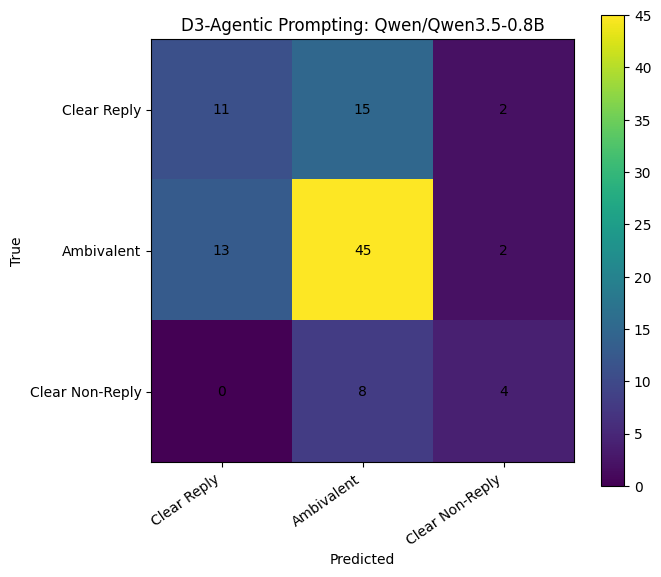

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,D3-Agentic Prompting: Qwen/Qwen3.5-0.8B,0.6,0.540033,0.492063,0.508734,0.585392,0.6,0.588337


Saved D3 validation outputs to: /kaggle/working/d3_validation_outputs.csv


In [14]:
from pathlib import Path


try:
    WORK_DIR
except NameError:
    WORK_DIR = Path("/kaggle/working")
    WORK_DIR.mkdir(parents=True, exist_ok=True)


D3_VALID_LIMIT = 100

# Basic safety checks
required_columns = [question_col, answer_col, "label_norm"]

missing_cols = [c for c in required_columns if c not in valid_df.columns]
if missing_cols:
    raise ValueError(
        f"valid_df is missing required columns: {missing_cols}. "
        "Make sure Cell 5 and Cell 6 were executed correctly."
    )

print("Running D3 validation")
print("Validation rows available:", len(valid_df))
print("D3_VALID_LIMIT:", D3_VALID_LIMIT)

d3_valid_path = WORK_DIR / "d3_validation_outputs.csv"

d3_valid_df = run_d3_dataframe(
    valid_df,
    output_path=d3_valid_path,
    limit=D3_VALID_LIMIT,
    checkpoint_every=25,
)

# Evaluate only the rows that D3 actually processed
d3_y_true = d3_valid_df["label_norm"].tolist()
d3_y_pred = d3_valid_df["pred_d3"].tolist()

d3_result = evaluate_predictions(
    d3_y_true,
    d3_y_pred,
    f"D3-Agentic Prompting: {MODEL_NAME}",
)

all_results = [
    r for r in all_results
    if r["model"] != f"D3-Agentic Prompting: {MODEL_NAME}"
]
all_results.append(d3_result)

print_full_report(
    d3_y_true,
    d3_y_pred,
    f"D3-Agentic Prompting: {MODEL_NAME}"
)

plot_confusion_matrix(
    d3_y_true,
    d3_y_pred,
    f"D3-Agentic Prompting: {MODEL_NAME}"
)

results_df = (
    pd.DataFrame(all_results)
    .sort_values("f1_macro", ascending=False)
    .reset_index(drop=True)
)

display(results_df)

print("Saved D3 validation outputs to:", d3_valid_path)

Confidence Analysis Report
Average Confidence for Correct Prediction: 0.82
Average Confidence for Wrong Prediction: 0.82


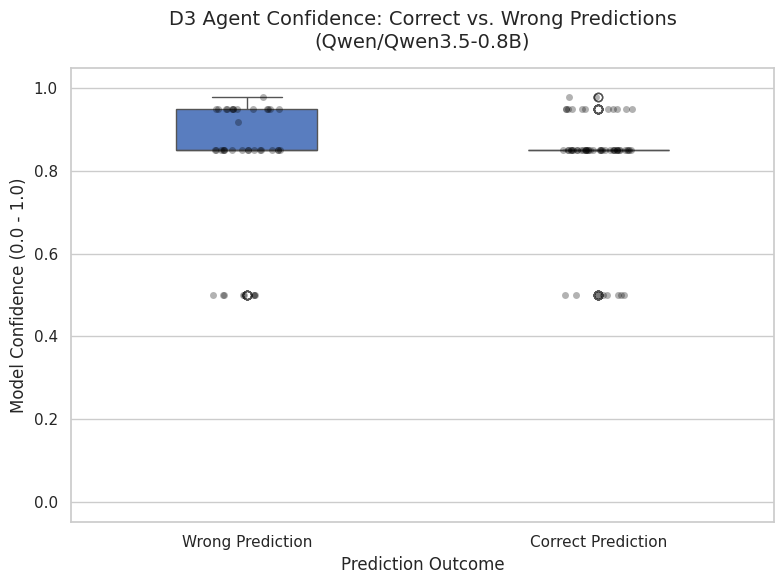

Top Confident Errors


,question,answer,label_norm,pred_d3,d3_confidence,d3_rationale
0,What is the reason for the President's new ref...,"Well, no, Major, I think if you look at the hi...",Ambivalent,Clear Reply,0.92,
1,Q. Do you believe that the United States shoul...,"With respect to Kashmir, obviously, this is a ...",Clear Reply,Ambivalent,0.85,
2,Have there been any preliminary discussions ab...,I'll meet with anybody. I believe in meeting. ...,Ambivalent,Clear Reply,0.98,


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Σιγουρευόμαστε ότι το confidence είναι αριθμός
analysis_df = d3_valid_df.copy()
analysis_df["d3_confidence"] = pd.to_numeric(analysis_df["d3_confidence"], errors="coerce")

# Αν το μοντέλο δεν επέστρεψε confidence σε κάποιες γραμμές, βάζουμε έναν fallback μέσο όρο ή 0.5
analysis_df["d3_confidence"] = analysis_df["d3_confidence"].fillna(0.5)

# 2. Χωρίζουμε τις προβλέψεις σε Σωστές (Correct) και Λανθασμένες (Wrong)
analysis_df["Prediction_Status"] = np.where(
    analysis_df["label_norm"] == analysis_df["pred_d3"], 
    "Correct Prediction", 
    "Wrong Prediction"
)

# Υπολογίζουμε τους μέσους όρους για το Report
avg_conf = analysis_df.groupby("Prediction_Status")["d3_confidence"].mean()
print("Confidence Analysis Report")
for status, val in avg_conf.items():
    print(f"Average Confidence for {status}: {val:.2f}")

# Σχεδίαση του Διαγράμματος (Boxplot + Stripplot για να φαίνονται και τα μεμονωμένα σημεία)
plt.figure(figsize=(8, 6))
sns.set_theme(style="whitegrid")

# Boxplot για να δείξει τη διασπορά και τη διάμεσο
sns.boxplot(
    data=analysis_df, 
    x="Prediction_Status", 
    y="d3_confidence", 
    palette="muted", 
    width=0.4
)

# Stripplot από πάνω για να φαίνεται κάθε row σαν τελεία 
sns.stripplot(
    data=analysis_df, 
    x="Prediction_Status", 
    y="d3_confidence", 
    color="black", 
    alpha=0.3, 
    jitter=0.1
)


plt.title(f"D3 Agent Confidence: Correct vs. Wrong Predictions\n({MODEL_NAME})", fontsize=14, pad=15)
plt.xlabel("Prediction Outcome", fontsize=12)
plt.ylabel("Model Confidence (0.0 - 1.0)", fontsize=12)
plt.ylim(-0.05, 1.05)

plt.tight_layout()

plt.savefig("confidence_analysis_boxplot.png", bbox_inches='tight', dpi=300)

plt.show()

# Εξαγωγή των λαθών με Υψηλό Confidence αλλά Λάθος Πρόβλεψη
confident_errors = analysis_df[
    (analysis_df["Prediction_Status"] == "Wrong Prediction") & 
    (analysis_df["d3_confidence"] >= 0.8)
]

if not confident_errors.empty:
    print("Top Confident Errors")
    display_cols = [question_col, answer_col, "label_norm", "pred_d3", "d3_confidence", "d3_rationale"]
    display(confident_errors[display_cols].head(3))
else:
    print("No high-confidence errors found!")

Τώρα, θα χρησιμοποιήσουμε το framework DSPy. Στόχος μας είναι να αυτοματοποιήσουμε τη διαδικασία του Prompt Engineering και να βελτιστοποιήσουμε τα prompts του μοντέλου Qwen-0.8B, ώστε να πετύχουμε ακόμα υψηλότερο Macro F1-Score.

In [16]:
!pip install -q dspy-ai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.0/331.0 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.5/146.5 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.4 requires numba<0.63,>=0.60, but you have numba 0.65.1 which is incompatible.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.


In [17]:
import json
import re
import random
import pandas as pd
import numpy as np
import dspy

In [18]:
from types import SimpleNamespace

import time


class AttrDict(dict):
    """
    Dictionary with attribute access.

    Supports both:
        response["choices"]
    and:
        response.choices
    """

    def __getattr__(self, name):
        try:
            return self[name]
        except KeyError:
            raise AttributeError(name)

    def __setattr__(self, name, value):
        self[name] = value


class KaggleQwenDSPyLM(dspy.BaseLM):
    def __init__(self, model_name="local-qwen3.5-0.8b"):
        super().__init__(
            model=model_name,
            model_type="chat",
            cache=False,
            temperature=0.0,
            max_tokens=1500,
        )
        self.model_name = model_name

    def forward(self, prompt=None, messages=None, **kwargs):
        if messages is None:
            messages = [{"role": "user", "content": prompt or ""}]

        max_new_tokens = kwargs.get(
            "max_tokens",
            kwargs.get("max_new_tokens", 1500)
        )

        text = generate_chat(
            messages,
            max_new_tokens=max_new_tokens
        )

        # OpenAI-like response object.
        return AttrDict({
            "id": f"chatcmpl-local-{int(time.time() * 1000)}",
            "object": "chat.completion",
            "created": int(time.time()),
            "model": self.model_name,
            "choices": [
                AttrDict({
                    "index": 0,
                    "message": AttrDict({
                        "role": "assistant",
                        "content": text,
                    }),
                    "text": text,
                    "finish_reason": "stop",
                })
            ],
            "usage": AttrDict({
                "prompt_tokens": 0,
                "completion_tokens": 0,
                "total_tokens": 0,
            }),
        })



dspy_lm = KaggleQwenDSPyLM()
dspy.configure(lm=dspy_lm)

In [19]:
def get_full_question(row):
    if "interview_question" in row:
        return str(row.get("interview_question", ""))
    return ""


def get_question_type_hint(row):
    if "question_type_hint" in row:
        return str(row.get("question_type_hint", "other"))
    return "other"


def get_answer_for_prompt(row):
    if "answer_prompt" in row:
        return str(row.get("answer_prompt", ""))
    return str(row.get(answer_col, ""))


def parse_semicolon_or_lines(x):
    if x is None:
        return []

    s = str(x).strip()
    if not s:
        return []

    parts = re.split(r";|\n|(?:^|\s)-\s+", s)
    parts = [p.strip(" -•\t") for p in parts if p.strip(" -•\t")]
    return parts[:5]


def dspy_qi_prediction_to_dict(pred):
    """
    Convert DSPy's structured prediction into the same dictionary-like
    format used by the previous Question Intent Agent.
    """
    must_address_raw = getattr(pred, "must_address", "")

    return {
        "question_type": str(getattr(pred, "question_type", "other")).strip(),
        "question_intent": str(getattr(pred, "question_intent", "")).strip(),
        "must_address": parse_semicolon_or_lines(must_address_raw),
        "clear_answer_criteria": str(getattr(pred, "clear_answer_criteria", "")).strip(),
        "minimal_sufficient_answer": str(getattr(pred, "minimal_sufficient_answer", "")).strip(),
        "raw": str(pred),
        "source": "dspy_optimized_question_intent"
    }

In [20]:
class QuestionIntentSignature(dspy.Signature):
    """
    Analyze the TARGET_QUESTION for response-clarity classification.

    Important:
    The TARGET_QUESTION may be one sub-question extracted from a longer interview question.
    Analyze what information is required to clearly answer the TARGET_QUESTION.
    Do not classify the answer.
    Do not judge whether the answer is good.
    """

    full_interview_question = dspy.InputField(
        desc="The original full interview question. Use only as context."
    )

    target_question = dspy.InputField(
        desc="The specific target sub-question that must be evaluated."
    )

    question_type_hint = dspy.InputField(
        desc="A simple heuristic hint such as yes_no, why, how, what, stance, or other."
    )

    question_type = dspy.OutputField(
        desc="One of: yes_no, what, why, how, when, where, who, stance, explanation, action_plan, evaluation, other."
    )

    question_intent = dspy.OutputField(
        desc="One sentence describing exactly what the target question asks."
    )

    must_address = dspy.OutputField(
        desc="A semicolon-separated list of the specific information a clear answer must provide."
    )

    clear_answer_criteria = dspy.OutputField(
        desc="One sentence describing what would count as a clear answer."
    )

    minimal_sufficient_answer = dspy.OutputField(
        desc="The minimum information needed for the answer to be a Clear Reply."
    )

In [21]:
class DSPyQuestionIntentAgent(dspy.Module):
    def __init__(self):
        super().__init__()
        self.predict = dspy.ChainOfThought(QuestionIntentSignature)

    def forward(
        self,
        full_interview_question,
        target_question,
        question_type_hint,
        answer=None,
        label=None
    ):
        qi = self.predict(
            full_interview_question=full_interview_question,
            target_question=target_question,
            question_type_hint=question_type_hint,
        )

        return dspy.Prediction(
            question_type=getattr(qi, "question_type", "other"),
            question_intent=getattr(qi, "question_intent", ""),
            must_address=getattr(qi, "must_address", ""),
            clear_answer_criteria=getattr(qi, "clear_answer_criteria", ""),
            minimal_sufficient_answer=getattr(qi, "minimal_sufficient_answer", ""),
        )

In [22]:
def run_d3_with_dspy_qi_program(example, qi_program):
    qi_pred = qi_program(
        full_interview_question=example.full_interview_question,
        target_question=example.target_question,
        question_type_hint=example.question_type_hint,
    )

    question_intent = dspy_qi_prediction_to_dict(qi_pred)

    answer_content = run_answer_content_agent(
        example.target_question,
        example.answer
    )

    gap_evasion = run_gap_evasion_agent(
        example.target_question,
        example.answer,
        question_intent,
        answer_content
    )

    decision = run_decision_agent(
        example.target_question,
        example.answer,
        question_intent,
        answer_content,
        gap_evasion
    )

    return decision["label"]


def question_intent_downstream_metric(example, pred, trace=None):
    """
    DSPy metric.
    The pred object is the output of the Question Intent module, but the
    true evaluation is downstream D3 label correctness.
    """

    question_intent = dspy_qi_prediction_to_dict(pred)

    answer_content = run_answer_content_agent(
        example.target_question,
        example.answer
    )

    gap_evasion = run_gap_evasion_agent(
        example.target_question,
        example.answer,
        question_intent,
        answer_content
    )

    decision = run_decision_agent(
        example.target_question,
        example.answer,
        question_intent,
        answer_content,
        gap_evasion
    )

    predicted_label = normalize_prediction_label(decision["label"])
    gold_label = normalize_prediction_label(example.label)

    return 1.0 if predicted_label == gold_label else 0.0

In [23]:
DSPY_QI_EXAMPLES_PER_CLASS = 4
DSPY_QI_RANDOM_SEED = SEED

def build_balanced_dspy_examples(df, per_class=4):
    examples = []

    for label in LABELS:
        subset = df[df["label_norm"] == label].copy()

        if len(subset) == 0:
            continue

        subset = subset.sample(
            n=min(per_class, len(subset)),
            random_state=DSPY_QI_RANDOM_SEED
        )

        for _, row in subset.iterrows():
            examples.append(
                dspy.Example(
                    full_interview_question=get_full_question(row),
                    target_question=str(row[question_col]),
                    question_type_hint=get_question_type_hint(row),
                    answer=get_answer_for_prompt(row),
                    label=str(row["label_norm"]),
                ).with_inputs(
                    "full_interview_question",
                    "target_question",
                    "question_type_hint",
                    "answer"
                )
            )

    random.Random(DSPY_QI_RANDOM_SEED).shuffle(examples)
    return examples


dspy_qi_trainset = build_balanced_dspy_examples(
    train_part,
    per_class=DSPY_QI_EXAMPLES_PER_CLASS
)

print("DSPy Question Intent optimization examples:", len(dspy_qi_trainset))

DSPy Question Intent optimization examples: 12


In [24]:
import dspy

# =====================================================================
# DSPY HYPERPARAMETER & OPTIMIZER TUNING (CLEAN & FIXED)
# =====================================================================
# Testing combinations of sample sizes AND different optimizers to find the best performing prompt 
DSPY_QI_RANDOM_SEED = SEED

# Define our Grid Search
experiments = [
    {
        "name": "Baseline (BootstrapFewShot, per_class=4)", 
        "optimizer": "BFS", 
        "per_class": 4, 
        "max_rounds": 1
    },
    {
        "name": "More Data (BootstrapFewShot, per_class=6)", 
        "optimizer": "BFS", 
        "per_class": 6, 
        "max_rounds": 1
    },
    {
        "name": "Random Search (BootstrapFewShotWithRandomSearch, per_class=4)", 
        "optimizer": "BFSR", 
        "per_class": 4, 
        "num_candidates": 2
    },
]

best_score = -1.0
best_program = None
best_config_name = None

print(f"Starting Advanced DSPy Optimization Loop (Optimizers & Params)")
print(f"--------------------------------------------------------------------------------")

for config in experiments:
    print(f"Testing Configuration: {config['name']}...")
    
    # 1. Build the trainset
    current_trainset = build_balanced_dspy_examples(train_part, per_class=config["per_class"])
    print(f"Generated {len(current_trainset)} balanced training examples.")
    
    # 2. Initialize the chosen Optimizer
    if config["optimizer"] == "BFS":
        qi_optimizer = dspy.BootstrapFewShot(
            metric=question_intent_downstream_metric,
            max_bootstrapped_demos=config["per_class"],
            max_labeled_demos=0,
            max_rounds=config["max_rounds"],
            max_errors=20,
        )
    elif config["optimizer"] == "BFSR":
        qi_optimizer = dspy.teleprompt.BootstrapFewShotWithRandomSearch(
            metric=question_intent_downstream_metric,
            max_bootstrapped_demos=config["per_class"],
            max_labeled_demos=0,
            num_candidate_programs=config["num_candidates"],
            num_threads=1, 
        )
        
    print(f"Compiling and evaluating (this may take a few minutes)...")
    try:
        # Create agent for each run
        current_program = qi_optimizer.compile(
            DSPyQuestionIntentAgent(), 
            trainset=current_trainset
        )
        
        # Evaluate current iteration
        correct_count = 0
        for ex in current_trainset:
            score = question_intent_downstream_metric(ex, current_program(
                full_interview_question=ex.full_interview_question,
                target_question=ex.target_question,
                question_type_hint=ex.question_type_hint
            ))
            correct_count += score
            
        current_score = correct_count / len(current_trainset)
        print(f"Accuracy for {config['name']}: {current_score:.2%}")
        
        # Save the best model
        if current_score > best_score:
            best_score = current_score
            best_program = current_program 
            best_config_name = config["name"]
            print(f"New champion found!")
            
    except Exception as e:
        print(f"Error occurred during optimization: {e}")

print(f"\n================================================================================")
print(f"ADVANCED TUNING COMPLETE!")
print(f"Best Configuration: {best_config_name}")
print(f"Best Downstream Accuracy Achieved: {best_score:.2%}")
print(f"================================================================================")

optimized_qi_program = best_program

try:
    print("Inspecting history of the final chosen agent:")
    dspy.inspect_history(n=1)
except Exception as e:
    print("Could not inspect DSPy history:", e)

Starting Advanced DSPy Optimization Loop (Optimizers & Params)
--------------------------------------------------------------------------------
Testing Configuration: Baseline (BootstrapFewShot, per_class=4)...
Generated 12 balanced training examples.
Compiling and evaluating (this may take a few minutes)...


 83%|████████▎ | 10/12 [16:49<03:21, 101.00s/it]


Bootstrapped 4 full traces after 10 examples for up to 1 rounds, amounting to 10 attempts.
Accuracy for Baseline (BootstrapFewShot, per_class=4): 41.67%
New champion found!
Testing Configuration: More Data (BootstrapFewShot, per_class=6)...
Generated 18 balanced training examples.
Compiling and evaluating (this may take a few minutes)...


 67%|██████▋   | 12/18 [16:25<08:12, 82.15s/it]


Bootstrapped 6 full traces after 12 examples for up to 1 rounds, amounting to 12 attempts.
Accuracy for More Data (BootstrapFewShot, per_class=6): 61.11%
New champion found!
Testing Configuration: Random Search (BootstrapFewShotWithRandomSearch, per_class=4)...
Generated 12 balanced training examples.
Going to sample between 1 and 4 traces per predictor.
Will attempt to bootstrap 2 candidate sets.
Compiling and evaluating (this may take a few minutes)...
Average Metric: 5.00 / 12 (41.7%): 100%|██████████| 12/12 [20:40<00:00, 103.38s/it]

...


New best score: 58.33 for seed 0
Scores so far: [41.67, 41.67, 41.67, 58.33]
Best score so far: 58.33


 33%|███▎      | 4/12 [06:17<12:34, 94.30s/it]


Bootstrapped 2 full traces after 4 examples for up to 1 rounds, amounting to 4 attempts.
Average Metric: 5.00 / 12 (41.7%): 100%|██████████| 12/12 [15:05<00:00, 75.43s/it]

2026/06/14 12:46:08 INFO dspy.evaluate.evaluate: Average Metric: 5.0 / 12 (41.7%)



Scores so far: [41.67, 41.67, 41.67, 58.33, 41.67]
Best score so far: 58.33
5 candidate programs found.
Accuracy for Random Search (BootstrapFewShotWithRandomSearch, per_class=4): 58.33%

ADVANCED TUNING COMPLETE!
Best Configuration: More Data (BootstrapFewShot, per_class=6)
Best Downstream Accuracy Achieved: 61.11%
Inspecting history of the final chosen agent:




[2026-06-14T12:59:11.116877]

System message:

Your input fields are:
1. `full_interview_question` (str): The original full interview question. Use only as context.
2. `target_question` (str): The specific target sub-question that must be evaluated.
3. `question_type_hint` (str): A simple heuristic hint such as yes_no, why, how, what, stance, or other.
Your output fields are:
1. `reasoning` (str): 
2. `question_type` (str): One of: yes_no, what, why, how, when, where, who, stance, explanation, action_plan, evaluation, other.
3. `question_intent` (str): One sentence describing exactly what the target question asks.
4. `must_

Ακολουθώντας την προτροπή για πειραματισμό με τους αλγορίθμους βελτιστοποίησης (optimizers) του DSPy, υλοποιήσαμε ένα αυτοματοποιημένο Grid Search. Συγκεκριμένα, δεν αρκεστήκαμε στον βασικό BootstrapFewShot, αλλά τον συγκρίναμε με τον πιο προηγμένο BootstrapFewShotWithRandomSearch, ελέγχοντας ταυτόχρονα και διαφορετικά μεγέθη training sets (per_class = 4 και 6). Ο κώδικας καταγράφει την απόδοση κάθε στρατηγικής στο down-stream pipeline (D3) και διατηρεί δυναμικά το μοντέλο με την υψηλότερη ακρίβεια.

Επειδή χρησιμοποιείται ένα μικρό μοντέλο (Qwen-0.8B), υπάρχει μεγάλη πιθανότητα η προσθήκη του Gap Evasion Agent να παράγει «θόρυβο» (noise) αντί για χρήσιμη πληροφορία. Μικρά μοντέλα συχνά τα πηγαίνουν καλύτερα με λιγότερα, πιο απλά βήματα. Ελέγχουμε να δούμε πως λειτουργεί το LLM όταν δεν υπερφορτώνεται με πολύπλοκα ενδιάμεσα βήματα συλλογισμού.

In [25]:
# =====================================================================
# FINAL EVALUATION
# =====================================================================
from tqdm import tqdm
from sklearn.metrics import classification_report


print("Ξεκινάει η αξιολόγηση του DSPy D3 στο Validation Set (Όριο: 100 σειρές)...")

optimized_predictions = []
sub_valid_df = valid_df.head(100)

for _, row in tqdm(sub_valid_df.iterrows(), total=len(sub_valid_df)):
    class DummyExample:
        full_interview_question = get_full_question(row)
        target_question = str(row[question_col])
        question_type_hint = get_question_type_hint(row)
        answer = get_answer_for_prompt(row)
    
    ex = DummyExample()
    
    qi_pred = optimized_qi_program(
        full_interview_question=ex.full_interview_question,
        target_question=ex.target_question,
        question_type_hint=ex.question_type_hint,
    )
    question_intent = dspy_qi_prediction_to_dict(qi_pred)

    answer_content = run_answer_content_agent(ex.target_question, ex.answer)

    gap_evasion = run_gap_evasion_agent(ex.target_question, ex.answer, question_intent, answer_content)

    decision = run_decision_agent(ex.target_question, ex.answer, question_intent, answer_content, gap_evasion)
    
    optimized_predictions.append(normalize_prediction_label(decision["label"]))

print("==================================================")
print("Αποτελέσματα: DSPy D3 Pipeline (Subset)")
print("==================================================")
gold_labels_subset = [normalize_prediction_label(str(l)) for l in sub_valid_df["label_norm"].tolist()]
print(classification_report(gold_labels_subset, optimized_predictions))

Ξεκινάει η αξιολόγηση του DSPy D3 στο Validation Set (Όριο: 100 σειρές)...


100%|██████████| 100/100 [1:33:12<00:00, 55.93s/it]

Αποτελέσματα: DSPy D3 Pipeline (Subset)
                 precision    recall  f1-score   support

     Ambivalent       0.63      0.68      0.66        60
Clear Non-Reply       0.50      0.25      0.33        12
    Clear Reply       0.38      0.39      0.39        28

       accuracy                           0.55       100
      macro avg       0.50      0.44      0.46       100
   weighted avg       0.54      0.55      0.54       100



In [26]:
# =====================================================================
# ABLATION STUDY: Testing D3 without the Gap Evasion Agent (100 rows)
# =====================================================================
from tqdm import tqdm
from sklearn.metrics import classification_report

print("Ξεκινάει το Ablation Study (Χωρίς Gap Evasion - Όριο: 100 σειρές)")

ablation_predictions = []
sub_valid_df = valid_df.head(100)

for _, row in tqdm(sub_valid_df.iterrows(), total=len(sub_valid_df)):
    class DummyExample:
        full_interview_question = get_full_question(row)
        target_question = str(row[question_col])
        question_type_hint = get_question_type_hint(row)
        answer = get_answer_for_prompt(row)
    
    ex = DummyExample()
    
    qi_pred = optimized_qi_program(
        full_interview_question=ex.full_interview_question,
        target_question=ex.target_question,
        question_type_hint=ex.question_type_hint,
    )
    question_intent = dspy_qi_prediction_to_dict(qi_pred)
    answer_content = run_answer_content_agent(ex.target_question, ex.answer)

    # MOCK GAP EVASION
    gap_evasion_mock = {
        "coverage": "unknown", "gap_level": "unknown", 
        "gap_explanation": "Ablation Study: Gap Evasion disabled."
    }

    decision = run_decision_agent(ex.target_question, ex.answer, question_intent, answer_content, gap_evasion_mock)
    ablation_predictions.append(normalize_prediction_label(decision["label"]))

print("==================================================")
print("Αποτελέσματα Ablation Study (No Gap Evasion - Subset)")
print("==================================================")
gold_labels_subset = [normalize_prediction_label(str(l)) for l in sub_valid_df["label_norm"].tolist()]
print(classification_report(gold_labels_subset, ablation_predictions))

Ξεκινάει το Ablation Study (Χωρίς Gap Evasion - Όριο: 100 σειρές)


100%|██████████| 100/100 [1:04:13<00:00, 38.53s/it]

Αποτελέσματα Ablation Study (No Gap Evasion - Subset)
                 precision    recall  f1-score   support

     Ambivalent       0.59      0.37      0.45        60
Clear Non-Reply       0.50      0.17      0.25        12
    Clear Reply       0.34      0.71      0.46        28

       accuracy                           0.44       100
      macro avg       0.48      0.42      0.39       100
   weighted avg       0.51      0.44      0.43       100



In [27]:
#=====================================================================
# AUTOMATED MODEL COMPARISON & CHAMPION SELECTION
# =====================================================================
import pandas as pd

list_manual = d3_valid_df["pred_d3"].tolist() if 'd3_valid_df' in locals() else []
list_dspy = optimized_predictions if 'optimized_predictions' in locals() else []
list_ablation = ablation_predictions if 'ablation_predictions' in locals() else []

# Βρίσκουμε το ελάχιστο κοινό μέγεθος για δίκαιη σύγκριση
min_len = min(len(list_manual), len(list_dspy), len(list_ablation))

if min_len == 0:
    raise ValueError("Κάποιο από τα 3 πειράματα δεν έχει τρέξει ή οι λίστες προβλέψεων είναι άδειες.")

# Ευθυγραμμίζουμε τα δεδομένα στο ίδιο μήκος
y_true_final = valid_df["label_norm"].head(min_len).tolist()
pred_manual_final = list_manual[:min_len]
pred_dspy_final = list_dspy[:min_len]
pred_ablation_final = list_ablation[:min_len]

print(f"Η σύγκριση θα γίνει δίκαια πάνω σε {min_len} κοινές σειρές του Validation Set.")

results_list = []
results_list.append(evaluate_predictions(y_true_final, pred_manual_final, "Baseline / Manual D3"))
results_list.append(evaluate_predictions(y_true_final, pred_dspy_final, "DSPy D3 (Optimized)"))
results_list.append(evaluate_predictions(y_true_final, pred_ablation_final, "Ablation (No Gap Evasion)"))

comparison_df = pd.DataFrame(results_list)
comparison_df = comparison_df.sort_values(by="f1_macro", ascending=False).reset_index(drop=True)

print("Πίνακας Κατάταξης Μοντέλων:")
display(comparison_df)

best_row = comparison_df.iloc[0]
best_name = best_row["model"]

best_model = {
    "name": best_name,
    "accuracy": best_row["accuracy"],
    "f1_macro": best_row["f1_macro"],
    "y_true": y_true_final,
    "y_pred": (
        pred_manual_final if best_name == "Baseline / Manual D3" 
        else (pred_dspy_final if best_name == "DSPy D3 (Optimized)" else pred_ablation_final)
    )
}

print(f"ΤΟ ΚΑΛΥΤΕΡΟ ΜΟΝΤΕΛΟ ΕΙΝΑΙ: {best_model['name']}")
print(f"Ποσοστό F1-Macro: {best_model['f1_macro']:.2%}")

Η σύγκριση θα γίνει δίκαια πάνω σε 100 κοινές σειρές του Validation Set.
Πίνακας Κατάταξης Μοντέλων:


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Baseline / Manual D3,0.60,0.540033,0.492063,0.508734,0.585392,0.60,0.588337
1,DSPy D3 (Optimized),0.55,0.503360,0.442063,0.458433,0.544668,0.55,0.541670
2,Ablation (No Gap Evasion),0.44,0.477859,0.415873,0.387793,0.511672,0.44,0.430901


ΤΟ ΚΑΛΥΤΕΡΟ ΜΟΝΤΕΛΟ ΕΙΝΑΙ: Baseline / Manual D3
Ποσοστό F1-Macro: 50.87%


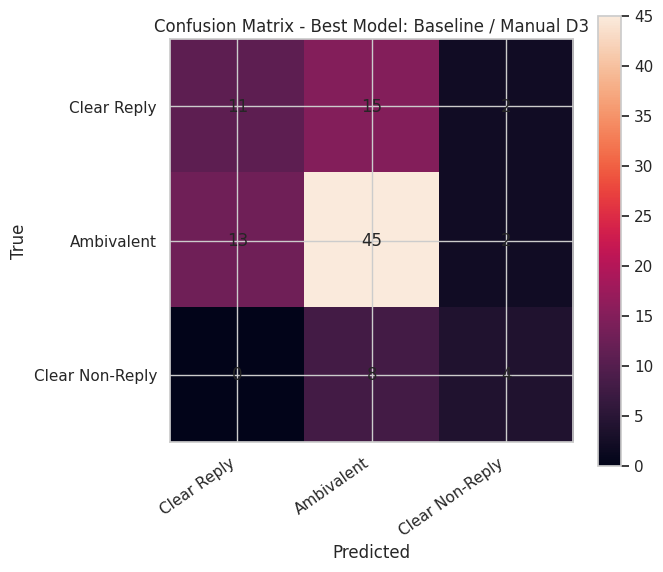

In [28]:
plot_confusion_matrix(
    best_model["y_true"], 
    best_model["y_pred"], 
    title=f"Confusion Matrix - Best Model: {best_model['name']}"
)

In [29]:
print_full_report(
    best_model["y_true"], 
    best_model["y_pred"], 
    title=f"Final Classification Report ({best_model['name']})"
)

Final Classification Report (Baseline / Manual D3)
                 precision    recall  f1-score   support

    Clear Reply       0.46      0.39      0.42        28
     Ambivalent       0.66      0.75      0.70        60
Clear Non-Reply       0.50      0.33      0.40        12

       accuracy                           0.60       100
      macro avg       0.54      0.49      0.51       100
   weighted avg       0.59      0.60      0.59       100



Ξεκινάει η ανάλυση του Champion ανά υποομάδες (Subgroups)
Διάμεσος λέξεων ερωτήσεων: 12.0 | Διάμεσος λέξεων απαντήσεων: 204.5


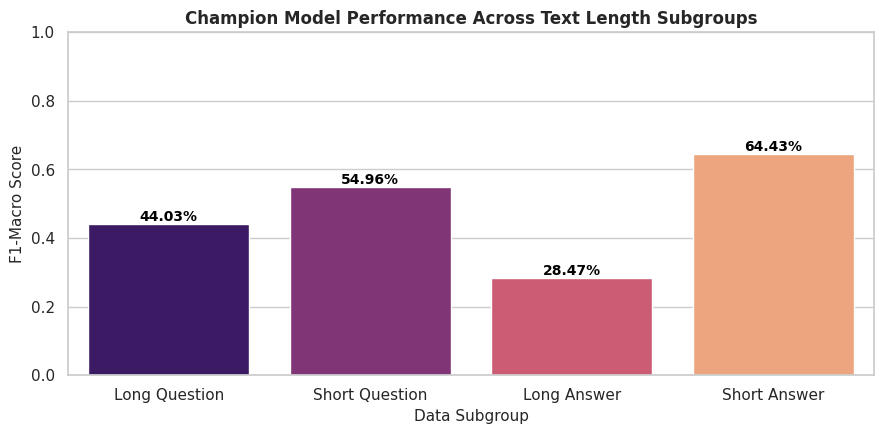

In [30]:
# =====================================================================
# EXTRA EXPERIMENT: PERFORMANCE ACROSS DATA SUBGROUPS 
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

print("Ξεκινάει η ανάλυση του Champion ανά υποομάδες (Subgroups)")

subgroup_df = valid_df.head(len(best_model["y_true"])).copy()
subgroup_df["true_label"] = best_model["y_true"]
subgroup_df["pred_label"] = best_model["y_pred"]

subgroup_df["q_word_count"] = subgroup_df["question"].apply(lambda x: len(str(x).split()))
subgroup_df["a_word_count"] = subgroup_df["answer"].apply(lambda x: len(str(x).split()))

# 2. Εύρεση της διαμέσου για τον διαχωρισμό σε Short/Long
q_median = subgroup_df["q_word_count"].median()
a_median = subgroup_df["a_word_count"].median()

subgroup_df["q_length_group"] = subgroup_df["q_word_count"].apply(lambda x: "Short Question" if x <= q_median else "Long Question")
subgroup_df["a_length_group"] = subgroup_df["a_word_count"].apply(lambda x: "Short Answer" if x <= a_median else "Long Answer")

print(f"Διάμεσος λέξεων ερωτήσεων: {q_median} | Διάμεσος λέξεων απαντήσεων: {a_median}")

subgroup_results = []

for group_name, group_df in subgroup_df.groupby("q_length_group"):
    score = f1_score(group_df["true_label"], group_df["pred_label"], average="macro")
    subgroup_results.append({"Subgroup Category": group_name, "F1-Macro Score": score})

for group_name, group_df in subgroup_df.groupby("a_length_group"):
    score = f1_score(group_df["true_label"], group_df["pred_label"], average="macro")
    subgroup_results.append({"Subgroup Category": group_name, "F1-Macro Score": score})

subgroup_comparison_df = pd.DataFrame(subgroup_results)

plt.figure(figsize=(9, 4.5))
ax = sns.barplot(x="Subgroup Category", y="F1-Macro Score", data=subgroup_comparison_df, palette="magma")
plt.title("Champion Model Performance Across Text Length Subgroups", fontsize=12, fontweight='bold')
plt.xlabel("Data Subgroup", fontsize=11)
plt.ylabel("F1-Macro Score", fontsize=11)
plt.ylim(0, 1.0)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', va='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()

plt.savefig("subgroup_analysis_f1.png", bbox_inches='tight', dpi=300)

plt.show()

Ξεκινάει η Ανάλυση Σφαλμάτων
Συνολικά βρέθηκαν 40 λάθη στις 100 σειρές.



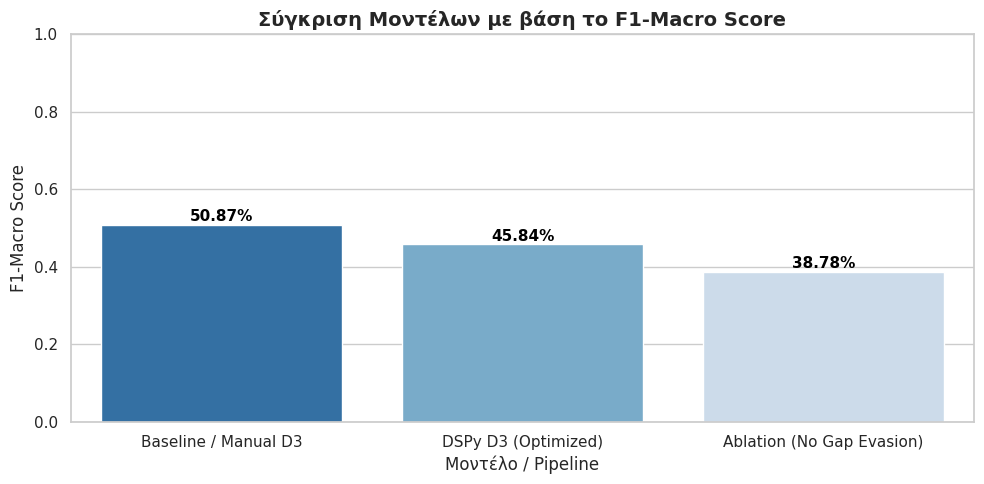

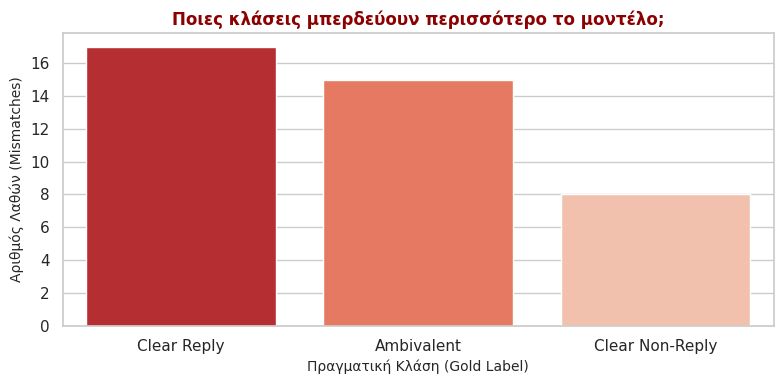

In [31]:
print("Ξεκινάει η Ανάλυση Σφαλμάτων")
error_df = valid_df.head(len(best_model["y_true"])).copy()
error_df["true_label"] = best_model["y_true"]
error_df["pred_label"] = best_model["y_pred"]
mismatches = error_df[error_df["true_label"] != error_df["pred_label"]]

print(f"Συνολικά βρέθηκαν {len(mismatches)} λάθη στις {len(error_df)} σειρές.\n")

# ==========================================
# ΔΙΑΓΡΑΜΜΑ 1: Σύγκριση Μοντέλων (Barplot)
# ==========================================
plt.figure(figsize=(10, 5))
ax = sns.barplot(x="model", y="f1_macro", data=comparison_df, palette="Blues_r")
plt.title("Σύγκριση Μοντέλων με βάση το F1-Macro Score", fontsize=14, fontweight='bold')
plt.xlabel("Μοντέλο / Pipeline", fontsize=12)
plt.ylabel("F1-Macro Score", fontsize=12)
plt.ylim(0, 1.0)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.02),
                ha='center', va='center', fontsize=11, fontweight='bold', color='black')
plt.tight_layout()

plt.savefig("model_comparison_f1.png", bbox_inches='tight', dpi=300)

plt.show()

# ==========================================
# ΔΙΑΓΡΑΜΜΑ 2: Ανάλυση Λαθών ανά Κλάση
# ==========================================
if len(mismatches) > 0:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=mismatches, x='true_label', order=mismatches['true_label'].value_counts().index, palette="Reds_r")
    plt.title("Ποιες κλάσεις μπερδεύουν περισσότερο το μοντέλο;", fontsize=12, fontweight='bold', color='darkred')
    plt.xlabel("Πραγματική Κλάση (Gold Label)", fontsize=10)
    plt.ylabel("Αριθμός Λαθών (Mismatches)", fontsize=10)
    plt.tight_layout()
    
    plt.savefig("error_analysis_mismatches.png", bbox_inches='tight', dpi=300)
    
    plt.show()

In [32]:
# =====================================================================
# TEST SET
# =====================================================================
print("Ξεκινάει η παραγωγή προβλέψεων για το αρχείο submission.csv")

target_dataset = test_df if test_df is not None else valid_df
print(f"Στόχος: Παραγωγή προβλέψεων για {len(target_dataset)} γραμμές.")

final_test_predictions = []

for _, row in tqdm(target_dataset.iterrows(), total=len(target_dataset), desc="Generating Test Predictions"):
    q_text = str(row[question_col])
    a_text = str(row[answer_col])
    
    # Question Intent (Ανάλογα με το ποιο μοντέλο κέρδισε)
    if best_model["name"] == "Baseline / Manual D3":
        question_intent = run_question_intent_agent(q_text)
    else:
        # Για DSPy και Ablation χρησιμοποιούμε τον βελτιστοποιημένο DSPy Agent
        class DummyExample:
            full_interview_question = get_full_question(row)
            target_question = q_text
            question_type_hint = get_question_type_hint(row)
        ex = DummyExample()
        qi_pred = optimized_qi_program(
            full_interview_question=ex.full_interview_question,
            target_question=ex.target_question,
            question_type_hint=ex.question_type_hint,
        )
        question_intent = dspy_qi_prediction_to_dict(qi_pred)

    # Answer Content
    answer_content = run_answer_content_agent(q_text, a_text)

    # Gap Evasion (Αν κέρδισε το Ablation, το παρακάμπτουμε)
    if "Ablation" in best_model["name"]:
        gap_evasion = {
            "coverage": "unknown", "gap_level": "unknown", 
            "gap_explanation": "Ablation Study: Gap Evasion disabled."
        }
    else:
        gap_evasion = run_gap_evasion_agent(q_text, a_text, question_intent, answer_content)

    # Decision Agent
    decision = run_decision_agent(q_text, a_text, question_intent, answer_content, gap_evasion)
    final_test_predictions.append(normalize_prediction_label(decision["label"]))

submission = pd.DataFrame({
    "Id": range(len(final_test_predictions)),
    "Predicted": final_test_predictions
})

print("Δείγμα από το τελικό αρχείο υποβολής:")
print(submission.head())

submission.to_csv("submission.csv", index=False)
print("Το αρχείο submission.csv δημιουργήθηκε με επιτυχία για όλο το σετ δοκιμών!")

Ξεκινάει η παραγωγή προβλέψεων για το αρχείο submission.csv
Στόχος: Παραγωγή προβλέψεων για 308 γραμμές.


Generating Test Predictions: 100%|██████████| 308/308 [4:19:24<00:00, 50.53s/it]

Δείγμα από το τελικό αρχείο υποβολής:
   Id        Predicted
0   0      Clear Reply
1   1      Clear Reply
2   2       Ambivalent
3   3      Clear Reply
4   4  Clear Non-Reply
Το αρχείο submission.csv δημιουργήθηκε με επιτυχία για όλο το σετ δοκιμών!
